# Lesson 139 · Clinical trials: transfer the pipeline, audit the target

Student lab · PROVIDED: inspect; TODO: implement; CHECK: run unchanged; EXIT: defend. Default execution audits a portable evidence packet and a synthetic full neural path. Fresh training is separately gated.

<!-- course-portable:start -->
### Follow the computation

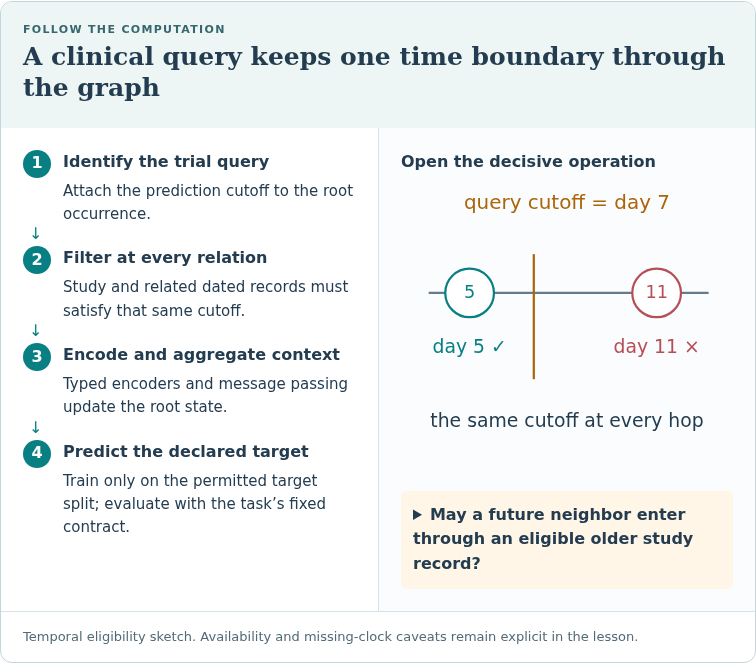

Temporal eligibility sketch. Availability and missing-clock caveats remain explicit in the lesson.

**Trace question:** May a future neighbor enter through an eligible older study record?

**Trace answer:** No. The path does not reset the query clock; every dated occurrence must pass the same boundary.
<!-- course-portable:end -->

In [ ]:
from pathlib import Path
import base64,hashlib,io,json
import numpy as np
import pandas as pd
from IPython.display import display
RUN_FULL_REPRODUCTION=False
PREPARED_ROOT=None  # Optional verified materialization directory; default prepares afresh.
# Enable only in the pinned GPU runtime, with sufficient host memory and budget.


In [ ]:
# PROVIDED: tie-aware rank arithmetic
def rank_auc(target,scores):
    """Positive-negative concordance with half credit for ties; O(n log n)."""
    y=np.asarray(target);s=np.asarray(scores,dtype=float)
    if y.ndim!=1 or s.shape!=y.shape or not np.isfinite(s).all() or not np.isin(y,[0,1]).all():
        raise ValueError('Aligned binary labels and finite scores required')
    positives=int(y.sum());negatives=len(y)-positives
    if positives==0 or negatives==0:raise ValueError('Both classes required')
    order=np.argsort(s,kind='stable');s=s[order];y=y[order]
    starts=np.r_[0,1+np.flatnonzero(s[1:]!=s[:-1])];ends=np.r_[starts[1:],len(s)]
    group_pos=np.add.reduceat(y,starts);group_neg=ends-starts-group_pos
    lower_neg=np.cumsum(group_neg)-group_neg
    return float(np.sum(group_pos*(lower_neg+.5*group_neg))/(positives*negatives))

<!-- sequence-review:start -->
<aside class="sequence-context" aria-label="Reading guide">
<p class="sequence-eyebrow">Transfer the pipeline, rebuild the question</p>
<p><strong>Reading route.</strong> Define the study population → trace a facility-to-study path → change the documented recipe → score keyed predictions.</p>
<details><summary>Quick prerequisite reminder</summary><p>A root is the study being predicted. Fanout limits how many neighbors are sampled per relation and hop. B is the number of queries in a batch; [B,128] means 128 learned coordinates for each query. BCE means binary cross-entropy, the training penalty for incorrect binary predictions. AUROC measures positive–negative ranking, with half credit for ties.</p></details>
</aside>
<!-- sequence-review:end -->



## 1 · What transfers when the domain changes?

[Lesson 138](https://avistian.github.io/relational/lessons/0138-ecommerce-amazon.html) followed customer → review → product paths. Now the root is a clinical study, connected to sponsors, conditions, interventions, facilities, and recorded results. The database changes; the row encoder → temporal neighborhood → GNN → task head structure survives. Your tangible win is to adapt that pipeline **and explain exactly which prediction problem you have built**.

Allow 25 minutes for the core lesson, then a separate lab session. Read [RelBench v1 Appendix B.2](https://arxiv.org/html/2407.20060v1#A2.SS2) for the trial-specific training exception; inspect the [released target SQL](https://avistian.github.io/relational/labs/sources/l139/relbench__tasks__trial.py) while working through the label.



| Contract | Amazon user-churn | Trial study-outcome |
|---|---|---|
| Query root | Customer | Study |
| Future window | 91 days | 365 days |
| Query inclusion | A recent review | Started study with a qualifying future analysis |
| Positive target | No future review | Minimum qualifying primary-outcome p-value ≤ 0.05 |
| Training | LR .005; sum; 128/64; 10 epochs | LR .0001; mean; 64/32; 20 epochs |
| Shared machinery | Row encoders, two-layer GNN, BCE, validation AUROC | Same computational structure; fresh weights |

This is **pipeline transfer**: rebuild the graph and train a new model. It is not zero-shot transfer of Amazon weights. The trial-specific settings come from the paper, before looking at our test results. [Paper §B.2](https://arxiv.org/html/2407.20060v1#A2.SS2)



## 2 · A missing result is not a negative result

**First, decode the clinical terms.** A primary outcome is a study’s designated main measurement. A p-value measures how incompatible the observed data are with a specified null hypothesis, under that statistical test’s assumptions. It is not the probability that a treatment works. Here the benchmark uses the recorded number and a threshold to construct a label; you do not need to derive the original clinical test. A modifier is a qualifier such as `<` or `>` attached to that recorded number.

Imagine a study that started on day −40. At cutoff day 0, we ask about primary analyses dated in **(0,365]**. A qualifying p-value of .03 yields label 1. A qualifying p-value of .12 yields label 0. No qualifying analysis yields **no query**. Assigning zero in that last case silently changes both the population and the target.

The source first joins analyses to outcomes and studies. It keeps primary outcomes with p-values in [0,1] and excludes modifier `>`; it then requires the study to have started by the cutoff and the analysis to occur within the future window. For each study/cutoff, it tests whether the minimum remaining numeric p-value is at most .05. A `<` modifier is retained but not interpreted as a numeric interval: `<.051` is handled as .051. Preserve this source behavior in a replay and describe its limit.

**Trace the minimum after filtering.** Keep the same study start day −40 and cutoff 0; place every analysis on future day 100. All modifiers are absent. Compare these three records:

<table class="compact-trace" style="min-width:0;border-collapse:separate;border-spacing:.4em .25em"><thead><tr><th>Record</th><th>Primary p-values</th><th>Secondary p-value</th><th>Label</th></tr></thead><tbody><tr><td>A</td><td>0.12</td><td>None</td><td>0</td></tr><tr><td>B</td><td>0.12, 0.04</td><td>None</td><td>1</td></tr><tr><td>C</td><td>0.12</td><td>0.001</td><td>0</td></tr></tbody></table>

B becomes positive because the minimum qualifying value is 0.04. Averaging 0.12 and 0.04 gives 0.08 and would implement a different label. C stays negative because the secondary analysis is filtered out *before* taking the minimum. A small number in a related row is insufficient unless that row meets the complete task contract.

**Transfer check.** Duplicate A's primary-analysis row ten times. The minimum and label remain unchanged. Add one qualifying primary analysis with p = 0.04 and the label changes to 1. Explain why this operational label depends on which qualifying analyses were recorded; it is not an average measure of treatment benefit.

<figure class="stream-figure" tabindex="0">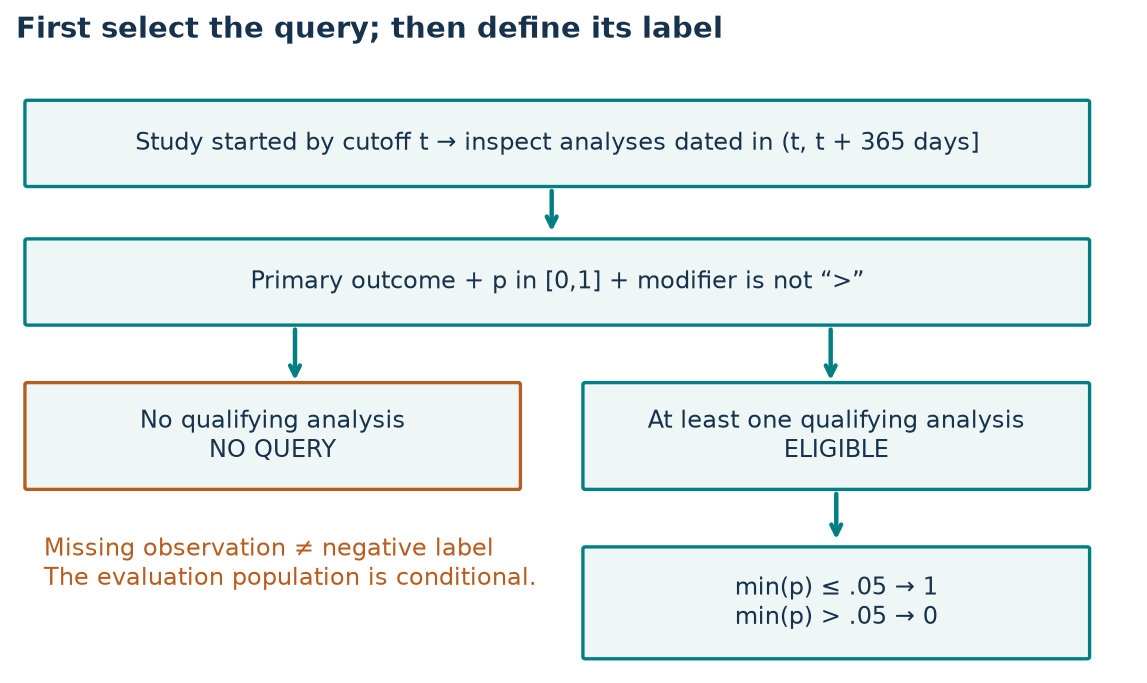<figcaption>The clinical target has two decisions: whether a query exists, then whether any qualifying primary analysis has p≤.05. On a narrow screen, scroll the diagram horizontally.</figcaption></figure>

**Predict:** a primary analysis exactly at day 365 has p=.05. Is the study included, and with which label? Move the analysis to day 366 before revealing the result.

Baseline day365: eligible, label1. Day366: absent query, not label0.

**TODO 1 — target contract.** Implement `trial_target(start, analyses, cutoff, horizon=365)`. Return `(False, None)` for an excluded query. Check date endpoints, invalid/missing p-values, primary versus secondary outcomes, and the source modifier rule. The function works in relative days; the author audit preserves full timestamps.

Implement this function in the live TODO below.

This operational label is not a treatment-effect estimate or proof of clinical benefit. The benchmark evaluates studies with qualifying recorded future analyses. Prospective deployment over *all* ongoing trials would need to address that different population. These are study-level registry records, not individual patient trajectories. Read the [dataset construction](https://avistian.github.io/relational/labs/sources/l139/relbench__datasets__trial.py) before describing the population.



In [ ]:
# TODO
def trial_target(start,analyses,cutoff,horizon=365):
    raise NotImplementedError("TODO: trial_target")

In [ ]:
# CHECK
def check_target(fn):
    # analyses: (day, p_value, p_value_modifier, outcome_type)
    assert fn(-1,[(1,.05,None,'Primary')],0)==(True,1)
    assert fn(-1,[(365,.051,None,'Primary')],0)==(True,0)
    assert fn(-1,[(0,.01,None,'Primary'),(366,.01,None,'Primary')],0)==(False,None)
    assert fn(1,[(10,.01,None,'Primary')],0)==(False,None)
    assert fn(0,[(1,.01,'>','Primary'),(2,.01,None,'Secondary')],0)==(False,None)
    assert fn(0,[(1,None,None,'Primary'),(2,-.1,None,'Primary'),(3,1.1,None,'Primary')],0)==(False,None)
    assert fn(0,[(1,.1,None,'Primary'),(2,.02,'<','Primary')],0)==(True,1)
    assert fn(0,[],0)==(False,None)
    assert fn(0,[(1,.051,'<','Primary')],0)==(True,0)
check_target(trial_target)
print("PASS: trial_target")

In [ ]:
RAW=base64.b64decode('...')
assert hashlib.sha256(RAW).hexdigest()=='dc546b04ee738f013dcafe8c0851269e3cc719288d20b1bd85e13f6aeaf6a6c8'
SAMPLES=json.loads(RAW)
for rows in SAMPLES.values():
    for row in rows:assert trial_target(row['start'],row['analyses'],0)==(True,row['target'])
print('PASS: real trial queries reconstructed with your target function')


## 3 · Reconstruct the population before fitting

A label can look plausible while the query set is wrong. We independently join the archived tables, rebuild inclusion and labels for every supplied timestamp, and compare both the complete key set and every label. We also execute the released SQL. Future outcome rows are needed for this audit; they do not become future input features.

| Split | Audited queries | Positive labels | Prevalence |
|---|---:|---:|---:|
| train | 11,994 | 7,647 | 0.6376 |
| val | 960 | 561 | 0.5844 |
| test | 825 | 483 | 0.5855 |

Full audit: **13779 queries**, zero label/key mismatches after applying the released split contract. 

**The domain-specific clock matters.** The released constructor assigns outcome/analysis dates from the study's completion date and assigns several design/association dates from its start date. These are inferred benchmark timestamps, not measured publication or database-arrival times. It also starts from studies with an actual completion date and a start date from 2000 onward. A past-only graph under these timestamps does not establish prospective availability in a live registry.

| Source field or construction | What it supports | What it does not establish |
|---|---|---|
| Study start date | Root/start cutoff check | When every study attribute was published |
| Completion date assigned to analyses | Benchmark future label window | When results became publicly available |
| Actual-completion cohort in the source snapshot | Released benchmark population | Coverage of every ongoing or abandoned trial |

[Inspect the constructor, especially inferred timestamps](https://avistian.github.io/relational/labs/sources/l139/relbench__datasets__trial.py). The raw archive supports label reconstruction beyond the test cutoff. The model snapshot is truncated at the dataset's test timestamp, 2021-01-01. Validation queries use 2020-01-01; a 365-day window is not always the same as “the same date next year.” Preserve exact timestamps and durations. [Dataset](https://avistian.github.io/relational/labs/sources/l139/relbench__datasets__trial.py) · [Task](https://avistian.github.io/relational/labs/sources/l139/relbench__tasks__trial.py)

**CHECK:** compare the released counts with paper Table 2: 11,994 train, 960 validation, 825 test. A matching count alone does not establish matching identities; the audit checks keys too. Archive matches establish the released data version, not the historical training RNG state.



## 4 · Model architecture: one query cutoff at every hop

A facility influences a study through `facilities_studies`; a condition uses `conditions_studies`. The association rows are themselves graph nodes. A two-layer model therefore reaches a facility or condition through two foreign-key edges. Outcome and analysis rows follow the same timestamp contract; even a perfectly predictive future p-value is unavailable to the query.

<figure class="stream-figure" tabindex="0">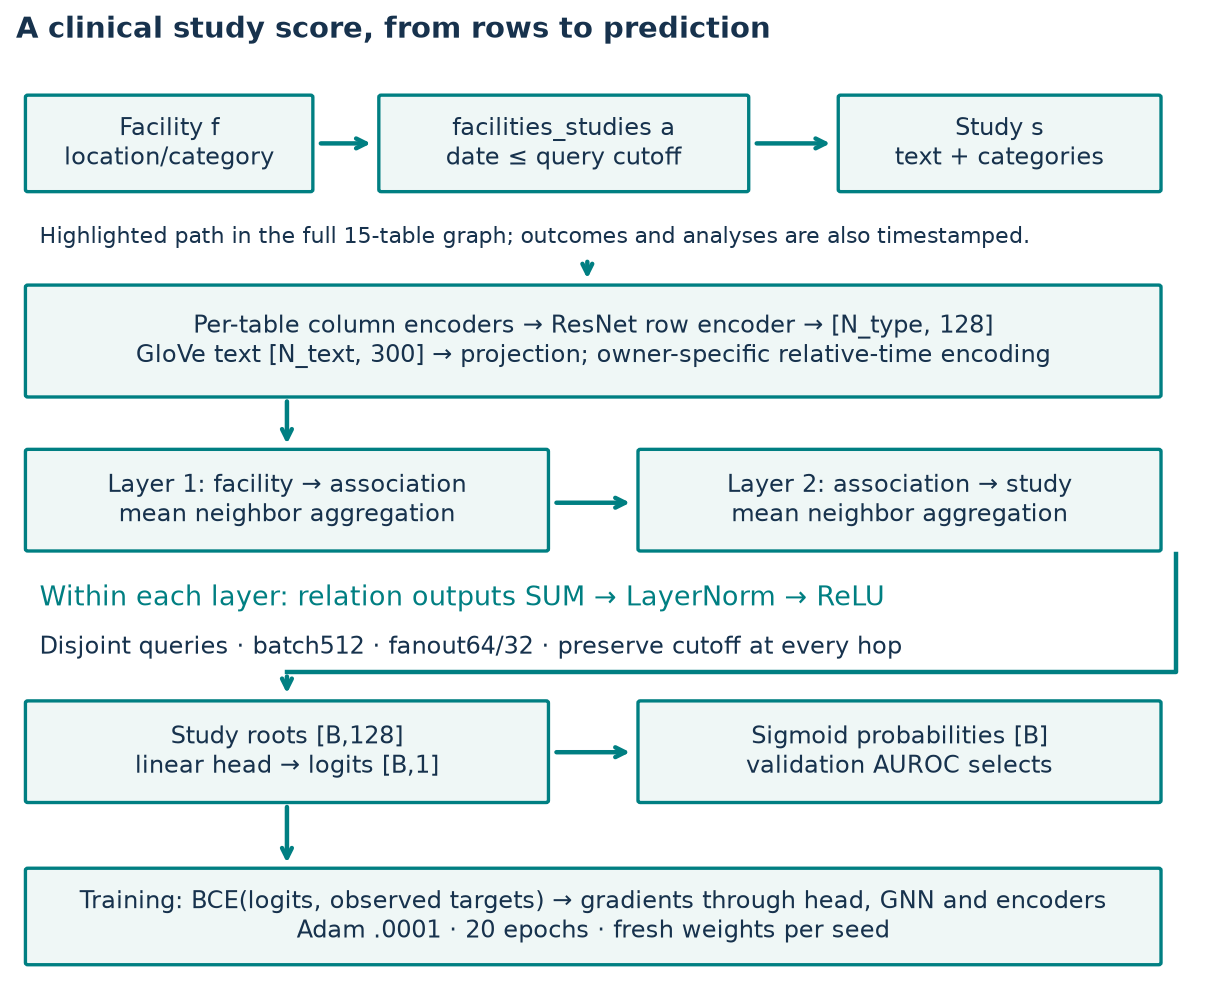<figcaption>Facility → association → study, within the full clinical graph. Mean neighbors, sum relations, owner-specific time, study head and training objective. On a narrow screen, scroll the diagram horizontally.</figcaption></figure>

The full model contains **15 node types, 5,434,924 nodes and 15,335,102 directed edges**, not just the highlighted path. Per-table PyTorch Frame encoders map numerical, categorical and text features to 128 channels. Text uses the pinned 300-dimensional mean GloVe representation. Relative-time encodings use each sampled node's owning query cutoff. Each GraphSAGE relation averages its neighbor messages; relation outputs are then **summed**, normalized and passed through ReLU. “Mean aggregation” does not mean averaging relation types. Two layers produce a study root vector [B,128]; a linear head yields [B,1] logits. BCE trains the model and validation AUROC selects its checkpoint.

The released loader halves the starting fanout across layers: 64,32. Sampling is per relation and disjoint per query. The same database row can appear twice in a batch with different owners and different allowed neighborhoods. [Visible implementation](https://avistian.github.io/relational/labs/relkit/rdl_l117.py) · [Released trainer](https://avistian.github.io/relational/labs/sources/l139/examples__gnn_node.py)

Baseline association time15: hidden for cutoff10, visible for cutoff20.

**TODO 2 — visibility contract.** Implement `visibility_mask(times, owners, cutoffs)`. Compare every node time with `cutoffs[owners]`. A batch maximum admits future rows for earlier queries. Equality is allowed by the released sampler; this is an event-time check. It does not prove that untimestamped metadata was known historically. The original feature statistics use the supplied snapshot; changing that preprocessing would create a different experiment.

Implement this function in the live TODO below.



In [ ]:
# TODO
def visibility_mask(times,owners,cutoffs):
    raise NotImplementedError("TODO: visibility_mask")

In [ ]:
# CHECK
def check_visibility(fn):
    assert fn([9,11,19,21],[0,0,1,1],[10,20]).tolist()==[True,False,True,False]
    assert fn([10,20],[0,1],[10,20]).all()
    assert fn([],[],[10]).tolist()==[]
    for times,owners,cuts in [([1],[2],[10]),([1,2],[0],[10]),([np.nan],[0],[10]),([1],[-1],[10])]:
        try:fn(times,owners,cuts)
        except ValueError:pass
        else:raise AssertionError('bad query ownership accepted')
check_visibility(visibility_mask)
print("PASS: visibility_mask")

## 5 · Transfer the pipeline, preserve the protocol

Keep the graph constructor, column encoders, temporal ownership, optimizer structure and validation selection visible. Change the dataset/task specification and the paper's documented trial settings. Do not tune on test results. The released epoch limit allows up to 2,001 batches; this small task finishes its complete training loader first.

| Item | Selected reproduction |
|---|---|
| Named target | RelBench v1 Table 6, basic RDL, rel-trial/study-outcome |
| Data | Full released graph and task splits; no feature or row caps |
| Fits | Five fresh seeds 0–4, each 20 epochs |
| Optimizer / loss | Adam, LR .0001 / BCE with logits |
| Model / loader | 2 × 128; mean neighbors; sum relations; batch 512; fanout 64/32; uniform temporal sampling |
| Selection | First strict maximum validation AUROC; selected state then re-evaluated |
| Preprocessing | Verified L132 materialization reused; seed 42, pinned GloVe; fresh materialization code supplied |
| Comparison | ±1 AUROC percentage point descriptive tolerance declared before training |

<figure class="stream-figure" tabindex="0">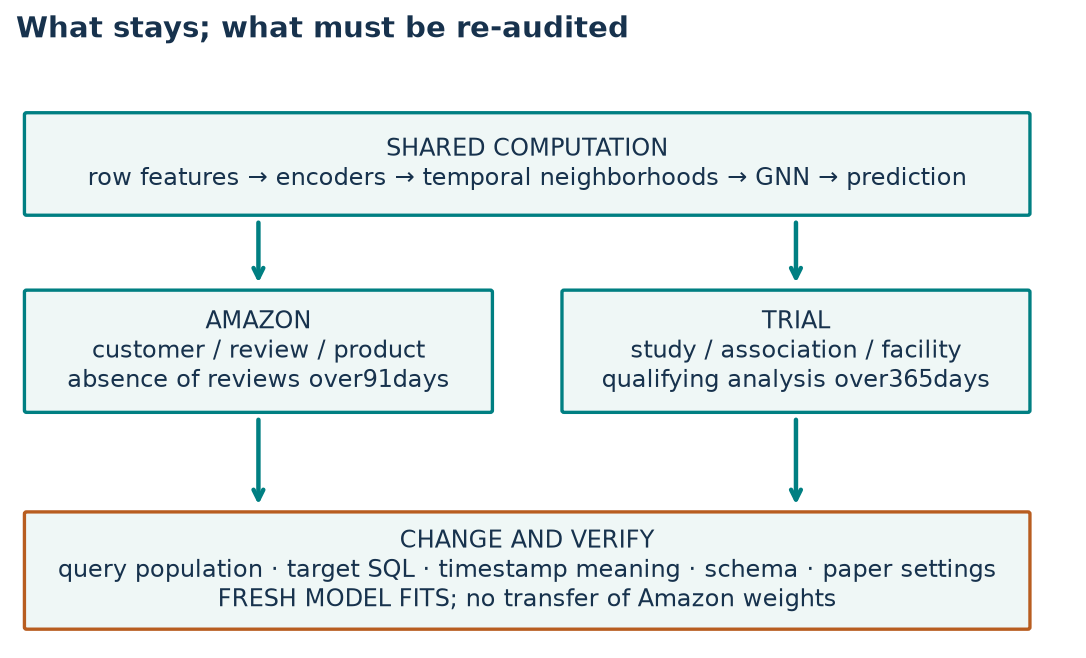<figcaption>Shared model computation transfers; query semantics, schema and paper settings are audited afresh. On a narrow screen, scroll the diagram horizontally.</figcaption></figure>

**Fresh reconstruction check:** a separate execution rebuilt all 15 tables and produced a byte-identical graph to the reused primary-run graph. This verifies the current preprocessing reuse; it does not establish the historical paper's RNG state. [Checksum evidence](https://avistian.github.io/relational/labs/evidence/l139/preprocessing_parity.json)

The lab includes the complete model, graph construction and trainer, plus a small forward/backward fixture. The default notebook checks the real evidence packet and learner functions. Enabling `RUN_FULL_REPRODUCTION` launches fresh training in the pinned runtime and requires substantial memory and compute. The supplied Modal operator reserves each attempt against the aggregate $10 budget. [Exact commands and limitations](https://avistian.github.io/relational/labs/l139-reproduction.md)



## 6 · Query identity comes before the score

Two predictions for the same study at different cutoffs are different queries. Align by **(study ID, cutoff)**, reject duplicates and missing keys, then compute AUROC. Reordering scores without reordering their keys can create a convincing but meaningless result.

**TODO 3 — evaluation contract.** Implement `keyed_auc(query_keys, targets, prediction_keys, scores)`. The provided `rank_auc` primitive awards half credit to tied positive–negative pairs. Your work is the identity contract: shuffled predictions must score identically, while duplicate or incomplete keys must fail.

Implement this function in the live TODO below.

**CHECK:** re-score every preserved validation/test prediction using your function, after intentionally shuffling the prediction rows. This verifies evaluation, not fresh training. Source-model checks and audited sampling provide different evidence and must be reported separately.



In [ ]:
# TODO
def keyed_auc(query_keys,targets,prediction_keys,scores):
    raise NotImplementedError("TODO: keyed_auc")

In [ ]:
# CHECK
def check_score(fn):
    keys=[(1,0),(2,0),(3,0),(4,0)];y=[0,0,1,1]
    assert fn(keys,y,keys[::-1],[2,1,1,0])==.875
    for pk,ps in [(keys[:-1],[0,1,2]),([keys[0]]*4,[0,1,2,3]),(keys[:-1]+[(9,0)],[0,1,2,3])]:
        try:fn(keys,y,pk,ps)
        except ValueError:pass
        else:raise AssertionError('invalid prediction keys accepted')
    assert fn([(1,0),(1,1)],[0,1],[(1,1),(1,0)],[.5,.5])==.5
check_score(keyed_auc)
print("PASS: keyed_auc")

## 7 · What did the complete experiment establish?

<figure class="stream-figure" tabindex="0">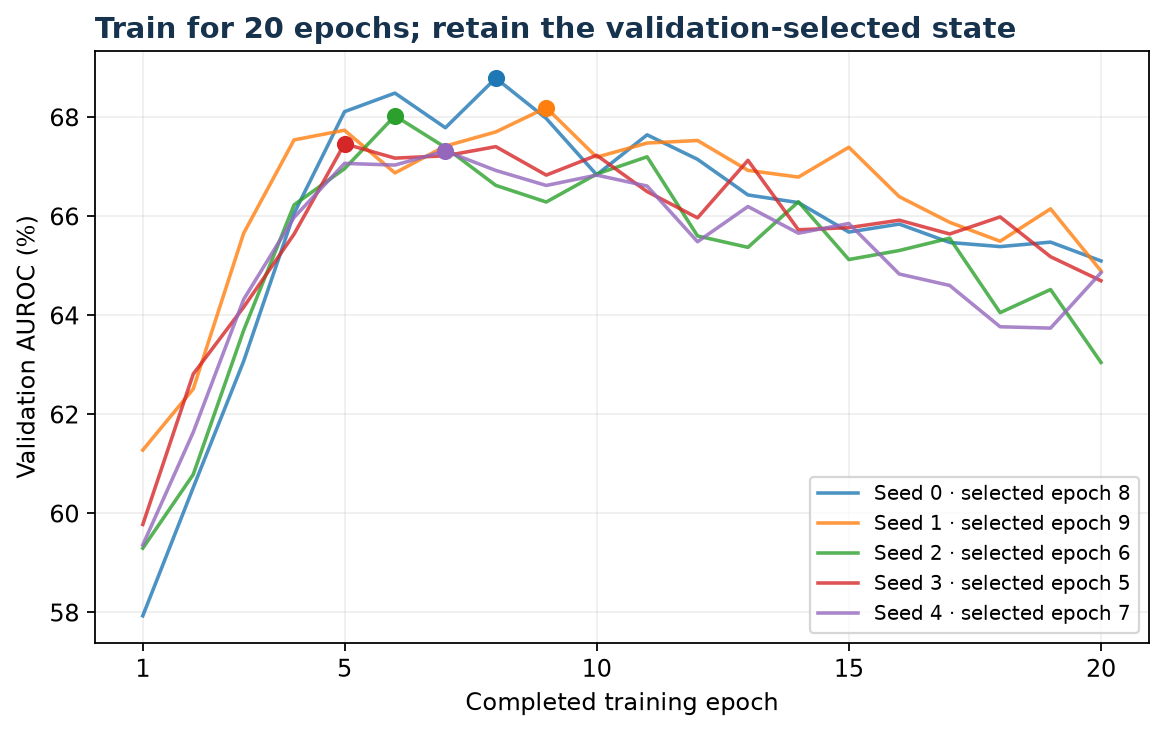<figcaption>Measured validation AUROC for all five complete fits. Dots mark first maxima; test scores play no role in checkpoint selection. On a narrow screen, scroll the diagram horizontally.</figcaption></figure>

**Complete selected released protocol** — Five full-data twenty-epoch fits completed; independently reconstructed all 13,779 queries and rescored all 8,925 held-out predictions. Trial-specific paper settings preserved.

| Split | Fresh AUROC % ± sample SD | Paper AUROC % ± SD | Descriptive comparison |
|---|---:|---:|---|
| val | 67.9432 ± 0.5851 | 68.18 ± .49 | CLOSE |
| test | 68.8891 ± 1.6141 | 68.60 ± 1.01 | CLOSE |

All 8,925 held-out neural predictions independently aligned and re-scored. 1,304,325 sampled query occurrences audited. Five full20-epoch fits; no post-test tuning. The ±1pp closeness rule is descriptive, not equivalence. Historical identity and whole-paper reproduction remain **NOT_ESTABLISHED**.

The paper's LightGBM comparison reports test AUROC 70.09±1.41 versus basic RDL 68.60±1.01. This lesson reproduces the selected GNN lane, not new LightGBM training. The paper notes that the study table already has rich features. Pipeline generality alone therefore does not establish a relational performance advantage. [Paper §5.1 and Table 6](https://arxiv.org/html/2407.20060v1#S5.SS1)

Inspect the [source manifest](https://avistian.github.io/relational/labs/sources/l139/manifest.json), [task audit](https://avistian.github.io/relational/labs/evidence/l139/task_audit.json), [run ledger](https://avistian.github.io/relational/labs/evidence/l139/reproduction.json), and [training results](https://avistian.github.io/relational/labs/evidence/l139/training.json). The lesson's measurements, source parity, browser checks, and your own mastery are separate claims. Live Colab and deployment remain unverified unless explicitly tested.



In [ ]:
PACKET=base64.b64decode('...')
assert hashlib.sha256(PACKET).hexdigest()=='cba6d0a4d999cce4b8a15aa331e218e9241272d75172f2fa10c10e2afe9ddf1d'
DATA=np.load(io.BytesIO(PACKET))


In [ ]:
EXPECTED={'val': 0.6794320918159927, 'test': 0.6888913104016079}
# Your visibility function audits a real sampled training batch.
node_occurrences=0
for key in DATA.files:
    if key.startswith('trace_') and key.endswith('_times'):
        owners=DATA[key[:-6]+'_owners'];times=DATA[key]
        assert visibility_mask(times,owners,DATA['trace_cutoffs']).all()
        node_occurrences+=len(times)
print('PASS: real sampled timestamped nodes',node_occurrences)
rows=[];rng=np.random.default_rng(139)
for split in ['val','test']:
    keys=list(zip(DATA[split+'_study'],DATA[split+'_time']));targets=DATA[split+'_target'];values=[]
    for seed in range(5):
        prefix=f's{seed}_{split}_'
        assert np.array_equal(targets,DATA[prefix+'target'])
        pkeys=list(zip(DATA[prefix+'study'],DATA[prefix+'time']))
        order=rng.permutation(len(pkeys))
        auc=keyed_auc(keys,targets,[pkeys[i] for i in order],DATA[prefix+'pred'][order])
        values.append(auc);rows.append(dict(split=split,seed=seed,queries=len(keys),auc=auc))
    assert abs(np.mean(values)-EXPECTED[split])<1e-12
display(pd.DataFrame(rows))
print('PASS: all ten full held-out score vectors independently keyed and rescored')


## 8 · Exit: defend the transfer





Write your four-paragraph defense and ask the teacher for feedback.

[Student notebook](https://avistian.github.io/relational/labs/0139-healthcare-trial.ipynb) · [Teacher solution](https://avistian.github.io/relational/labs/solutions/0139-healthcare-trial.ipynb) · [Prepared walkthrough](https://avistian.github.io/relational/labs/html/0139-healthcare-trial.html) · [Reference](https://avistian.github.io/relational/reference/healthcare-trial.html). Ask the teacher about any unclear step, or submit the four paragraphs for feedback. Revisit the missing-result and two-cutoff examples tomorrow; the following checkpoint will compare evidence across tasks.


<!-- sequence-next:start -->
**Carry this forward.** Keep both domain contracts. Lesson 140 asks you to defend complete runs, numerical closeness and protocol evidence as separate verdicts. [Continue to Lesson 140](https://avistian.github.io/relational/lessons/0140-rdl-reproduction-checkpoint.html).
<!-- sequence-next:end -->


## PROVIDED · complete model and graph construction

Read the encoder, owner-specific temporal encoding, relation convolution, root selection and head. The fixture executes the whole neural path; it is separate from the full-data score experiment.

In [ ]:
# The MIT License (MIT)
# 
# Copyright (c) 2023 RelBench Team
# 
# Permission is hereby granted, free of charge, to any person obtaining a copy
# of this software and associated documentation files (the "Software"), to deal
# in the Software without restriction, including without limitation the rights
# to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
# copies of the Software, and to permit persons to whom the Software is
# furnished to do so, subject to the following conditions:
# 
# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.
# 
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
# AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
# OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN
# THE SOFTWARE.

from typing import Any, Dict, List, Optional

import torch
import torch_frame
from torch import Tensor
from torch_frame.data.stats import StatType
from torch_frame.nn.models import ResNet
from torch_geometric.nn import HeteroConv, LayerNorm, PositionalEncoding, SAGEConv
from torch_geometric.typing import EdgeType, NodeType


class HeteroEncoder(torch.nn.Module):
    r"""HeteroEncoder based on PyTorch Frame.

    Args:
        channels (int): The output channels for each node type.
        node_to_col_names_dict (Dict[NodeType, Dict[torch_frame.stype, List[str]]]):
            A dictionary mapping from node type to column names dictionary
            compatible to PyTorch Frame.
        torch_frame_model_cls: Model class for PyTorch Frame. The class object
            takes :class:`TensorFrame` object as input and outputs
            :obj:`channels`-dimensional embeddings. Default to
            :class:`torch_frame.nn.ResNet`.
        torch_frame_model_kwargs (Dict[str, Any]): Keyword arguments for
            :class:`torch_frame_model_cls` class. Default keyword argument is
            set specific for :class:`torch_frame.nn.ResNet`. Expect it to
            be changed for different :class:`torch_frame_model_cls`.
        default_stype_encoder_cls_kwargs (Dict[torch_frame.stype, Any]):
            A dictionary mapping from :obj:`torch_frame.stype` object into a
            tuple specifying :class:`torch_frame.nn.StypeEncoder` class and its
            keyword arguments :obj:`kwargs`.
    """

    def __init__(
        self,
        channels: int,
        node_to_col_names_dict: Dict[NodeType, Dict[torch_frame.stype, List[str]]],
        node_to_col_stats: Dict[NodeType, Dict[str, Dict[StatType, Any]]],
        torch_frame_model_cls=ResNet,
        torch_frame_model_kwargs: Dict[str, Any] = {
            "channels": 128,
            "num_layers": 4,
        },
        default_stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any] = {
            torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}),
            torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}),
            torch_frame.multicategorical: (
                torch_frame.nn.MultiCategoricalEmbeddingEncoder,
                {},
            ),
            torch_frame.embedding: (torch_frame.nn.LinearEmbeddingEncoder, {}),
            torch_frame.timestamp: (torch_frame.nn.TimestampEncoder, {}),
        },
    ):
        super().__init__()

        self.encoders = torch.nn.ModuleDict()

        for node_type in node_to_col_names_dict.keys():
            stype_encoder_dict = {
                stype: default_stype_encoder_cls_kwargs[stype][0](
                    **default_stype_encoder_cls_kwargs[stype][1]
                )
                for stype in node_to_col_names_dict[node_type].keys()
            }
            torch_frame_model = torch_frame_model_cls(
                **torch_frame_model_kwargs,
                out_channels=channels,
                col_stats=node_to_col_stats[node_type],
                col_names_dict=node_to_col_names_dict[node_type],
                stype_encoder_dict=stype_encoder_dict,
            )
            self.encoders[node_type] = torch_frame_model

    def reset_parameters(self):
        for encoder in self.encoders.values():
            encoder.reset_parameters()

    def forward(
        self,
        tf_dict: Dict[NodeType, torch_frame.TensorFrame],
    ) -> Dict[NodeType, Tensor]:
        x_dict = {
            node_type: self.encoders[node_type](tf) for node_type, tf in tf_dict.items()
        }
        return x_dict


class HeteroTemporalEncoder(torch.nn.Module):
    def __init__(self, node_types: List[NodeType], channels: int):
        super().__init__()

        self.encoder_dict = torch.nn.ModuleDict(
            {node_type: PositionalEncoding(channels) for node_type in node_types}
        )
        self.lin_dict = torch.nn.ModuleDict(
            {node_type: torch.nn.Linear(channels, channels) for node_type in node_types}
        )

    def reset_parameters(self):
        for encoder in self.encoder_dict.values():
            encoder.reset_parameters()
        for lin in self.lin_dict.values():
            lin.reset_parameters()

    def forward(
        self,
        seed_time: Tensor,
        time_dict: Dict[NodeType, Tensor],
        batch_dict: Dict[NodeType, Tensor],
    ) -> Dict[NodeType, Tensor]:
        out_dict: Dict[NodeType, Tensor] = {}

        for node_type, time in time_dict.items():
            rel_time = seed_time[batch_dict[node_type]] - time
            rel_time = rel_time / (60 * 60 * 24)  # Convert seconds to days.

            x = self.encoder_dict[node_type](rel_time)
            x = self.lin_dict[node_type](x)
            out_dict[node_type] = x

        return out_dict


class HeteroGraphSAGE(torch.nn.Module):
    def __init__(
        self,
        node_types: List[NodeType],
        edge_types: List[EdgeType],
        channels: int,
        aggr: str = "mean",
        num_layers: int = 2,
    ):
        super().__init__()

        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            conv = HeteroConv(
                {
                    edge_type: SAGEConv((channels, channels), channels, aggr=aggr)
                    for edge_type in edge_types
                },
                aggr="sum",
            )
            self.convs.append(conv)

        self.norms = torch.nn.ModuleList()
        for _ in range(num_layers):
            norm_dict = torch.nn.ModuleDict()
            for node_type in node_types:
                norm_dict[node_type] = LayerNorm(channels, mode="node")
            self.norms.append(norm_dict)

    def reset_parameters(self):
        for conv in self.convs:
            conv.reset_parameters()
        for norm_dict in self.norms:
            for norm in norm_dict.values():
                norm.reset_parameters()

    def forward(
        self,
        x_dict: Dict[NodeType, Tensor],
        edge_index_dict: Dict[NodeType, Tensor],
        num_sampled_nodes_dict: Optional[Dict[NodeType, List[int]]] = None,
        num_sampled_edges_dict: Optional[Dict[EdgeType, List[int]]] = None,
    ) -> Dict[NodeType, Tensor]:
        for _, (conv, norm_dict) in enumerate(zip(self.convs, self.norms)):
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: norm_dict[key](x) for key, x in x_dict.items()}
            x_dict = {key: x.relu() for key, x in x_dict.items()}

        return x_dict

# %% Relational node predictor (PROVIDED)
from typing import Any, Dict, List

import torch
from torch import Tensor
from torch.nn import Embedding, ModuleDict
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.nn import MLP
from torch_geometric.typing import NodeType




class Model(torch.nn.Module):

    def __init__(
        self,
        data: HeteroData,
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        num_layers: int,
        channels: int,
        out_channels: int,
        aggr: str,
        norm: str,
        # List of node types to add shallow embeddings to input
        shallow_list: List[NodeType] = [],
        # ID awareness
        id_awareness: bool = False,
    ):
        super().__init__()

        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={
                node_type: data[node_type].tf.col_names_dict
                for node_type in data.node_types
            },
            node_to_col_stats=col_stats_dict,
        )
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[
                node_type for node_type in data.node_types if "time" in data[node_type]
            ],
            channels=channels,
        )
        self.gnn = HeteroGraphSAGE(
            node_types=data.node_types,
            edge_types=data.edge_types,
            channels=channels,
            aggr=aggr,
            num_layers=num_layers,
        )
        self.head = MLP(
            channels,
            out_channels=out_channels,
            norm=norm,
            num_layers=1,
        )
        self.embedding_dict = ModuleDict(
            {
                node: Embedding(data.num_nodes_dict[node], channels)
                for node in shallow_list
            }
        )

        self.id_awareness_emb = None
        if id_awareness:
            self.id_awareness_emb = torch.nn.Embedding(1, channels)
        self.reset_parameters()

    def reset_parameters(self):
        self.encoder.reset_parameters()
        self.temporal_encoder.reset_parameters()
        self.gnn.reset_parameters()
        self.head.reset_parameters()
        for embedding in self.embedding_dict.values():
            torch.nn.init.normal_(embedding.weight, std=0.1)
        if self.id_awareness_emb is not None:
            self.id_awareness_emb.reset_parameters()

    def forward(
        self,
        batch: HeteroData,
        entity_table: NodeType,
    ) -> Tensor:
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
            batch.num_sampled_nodes_dict,
            batch.num_sampled_edges_dict,
        )

        return self.head(x_dict[entity_table][: seed_time.size(0)])


# %% Full database to REG and query transform (PROVIDED)
import os
from typing import Any, Dict, NamedTuple, Optional, Tuple

import numpy as np
import pandas as pd
import torch
from torch import Tensor
from torch_frame import stype
from torch_frame.config import TextEmbedderConfig
from torch_frame.data import Dataset
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.typing import NodeType
from torch_geometric.utils import sort_edge_index

from relbench.base import Database, EntityTask, RecommendationTask, Table, TaskType
from relbench.modeling.utils import remove_pkey_fkey, to_unix_time


def make_pkey_fkey_graph(
    db: Database,
    col_to_stype_dict: Dict[str, Dict[str, stype]],
    text_embedder_cfg: Optional[TextEmbedderConfig] = None,
    cache_dir: Optional[str] = None,
) -> Tuple[HeteroData, Dict[str, Dict[str, Dict[StatType, Any]]]]:
    r"""Given a :class:`Database` object, construct a heterogeneous graph with primary-
    foreign key relationships, together with the column stats of each table.

    Args:
        db: A database object containing a set of tables.
        col_to_stype_dict: Column to stype for
            each table.
        text_embedder_cfg: Text embedder config.
        cache_dir: A directory for storing materialized tensor
            frames. If specified, we will either cache the file or use the
            cached file. If not specified, we will not use cached file and
            re-process everything from scratch without saving the cache.

    Returns:
        HeteroData: The heterogeneous :class:`PyG` object with
            :class:`TensorFrame` feature.
    """
    data = HeteroData()
    col_stats_dict = dict()
    if cache_dir is not None:
        os.makedirs(cache_dir, exist_ok=True)

    for table_name, table in db.table_dict.items():
        # Materialize the tables into tensor frames:
        df = table.df
        # Ensure that pkey is consecutive.
        if table.pkey_col is not None:
            assert (df[table.pkey_col].values == np.arange(len(df))).all()

        col_to_stype = col_to_stype_dict[table_name]

        # Remove pkey, fkey columns since they will not be used as input
        # feature.
        remove_pkey_fkey(col_to_stype, table)

        if len(col_to_stype) == 0:  # Add constant feature in case df is empty:
            col_to_stype = {"__const__": stype.numerical}
            # We need to add edges later, so we need to also keep the fkeys
            fkey_dict = {key: df[key] for key in table.fkey_col_to_pkey_table}
            df = pd.DataFrame({"__const__": np.ones(len(table.df)), **fkey_dict})

        path = (
            None if cache_dir is None else os.path.join(cache_dir, f"{table_name}.pt")
        )

        dataset = Dataset(
            df=df,
            col_to_stype=col_to_stype,
            col_to_text_embedder_cfg=text_embedder_cfg,
        ).materialize(path=path)

        data[table_name].tf = dataset.tensor_frame
        col_stats_dict[table_name] = dataset.col_stats

        # Add time attribute:
        if table.time_col is not None:
            data[table_name].time = torch.from_numpy(
                to_unix_time(table.df[table.time_col])
            )

        # Add edges:
        for fkey_name, pkey_table_name in table.fkey_col_to_pkey_table.items():
            pkey_index = df[fkey_name]
            # Filter out dangling foreign keys
            mask = ~pkey_index.isna()
            fkey_index = torch.arange(len(pkey_index))
            # Filter dangling foreign keys:
            pkey_index = torch.from_numpy(pkey_index[mask].astype(int).values)
            fkey_index = fkey_index[torch.from_numpy(mask.values)]
            # Ensure no dangling fkeys
            assert (pkey_index < len(db.table_dict[pkey_table_name])).all()

            # fkey -> pkey edges
            edge_index = torch.stack([fkey_index, pkey_index], dim=0)
            edge_type = (table_name, f"f2p_{fkey_name}", pkey_table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

            # pkey -> fkey edges.
            # "rev_" is added so that PyG loader recognizes the reverse edges
            edge_index = torch.stack([pkey_index, fkey_index], dim=0)
            edge_type = (pkey_table_name, f"rev_f2p_{fkey_name}", table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

    data.validate()

    return data, col_stats_dict


class AttachTargetTransform:
    r"""Attach the target label to the heterogeneous mini-batch.

    The batch consists of disjoins subgraphs loaded via temporal sampling. The same
    input node can occur multiple times with different timestamps, and thus different
    subgraphs and labels. Hence labels cannot be stored in the graph object directly,
    and must be attached to the batch after the batch is created.
    """

    def __init__(self, entity: str, target: Tensor):
        self.entity = entity
        self.target = target

    def __call__(self, batch: HeteroData) -> HeteroData:
        batch[self.entity].y = self.target[batch[self.entity].input_id]
        return batch


class NodeTrainTableInput(NamedTuple):
    r"""Training table input for node prediction.

    - nodes is a Tensor of node indices.
    - time is a Tensor of node timestamps.
    - target is a Tensor of node labels.
    - transform attaches the target to the batch.
    """

    nodes: Tuple[NodeType, Tensor]
    time: Optional[Tensor]
    target: Optional[Tensor]
    transform: Optional[AttachTargetTransform]


def get_node_train_table_input(
    table: Table,
    task: EntityTask,
) -> NodeTrainTableInput:
    r"""Get the training table input for node prediction."""

    nodes = torch.from_numpy(table.df[task.entity_col].astype(int).values)

    time: Optional[Tensor] = None
    if table.time_col is not None:
        time = torch.from_numpy(to_unix_time(table.df[table.time_col]))

    target: Optional[Tensor] = None
    transform: Optional[AttachTargetTransform] = None
    if task.target_col in table.df:
        target_type = float
        if task.task_type == TaskType.MULTICLASS_CLASSIFICATION:
            target_type = int
        if task.task_type == TaskType.MULTILABEL_CLASSIFICATION:
            target = torch.from_numpy(np.stack(table.df[task.target_col].values))
        else:
            target = torch.from_numpy(
                table.df[task.target_col].values.astype(target_type)
            )
        transform = AttachTargetTransform(task.entity_table, target)

    return NodeTrainTableInput(
        nodes=(task.entity_table, nodes),
        time=time,
        target=target,
        transform=transform,
    )




In [ ]:
"""Small complete RDL forward/backward, separate from clinical trial training."""
import copy
import pandas as pd
import torch
from torch_frame import stype
from torch_frame.data import Dataset
from torch_geometric.data import HeteroData

def neural_fixture(Model):
    torch.set_num_threads(1);torch.manual_seed(139)
    data=HeteroData();stats={}
    for kind,values in [('studies',[1.,2.,3.,4.]),('facilities_studies',[3.,5.,9.,10.]),('facilities',[2.,7.,11.,16.])]:
        frame=Dataset(pd.DataFrame({'x':values}),col_to_stype={'x':stype.numerical}).materialize()
        data[kind].tf=frame.tensor_frame;stats[kind]=frame.col_stats
        data[kind].batch=torch.tensor([0,1,0,1]);data[kind].n_id=torch.arange(4);data[kind].num_sampled_nodes=[2,1,1]
    data['studies'].seed_time=torch.tensor([864000,1728000]);data['facilities_studies'].time=torch.tensor([777600,1555200,691200,1468800])
    for src,dst in [('facilities_studies','studies'),('facilities_studies','facilities')]:
        edge=torch.tensor([[0,1,2,3],[0,1,0,1]])
        data[src,'to',dst].edge_index=edge;data[dst,'rev_to',src].edge_index=edge.flip(0)
    for kind in data.edge_types:data[kind].num_sampled_edges=[2,2]
    model=Model(data,stats,2,128,1,'mean','batch_norm');model.train()
    logits=model(data,'studies').view(-1);assert logits.shape==(2,)
    loss=torch.nn.functional.binary_cross_entropy_with_logits(logits,torch.tensor([0.,1.]));loss.backward()
    for name,part in [('encoder',model.encoder),('gnn',model.gnn),('head',model.head)]:
        gradients=[p.grad for p in part.parameters() if p.grad is not None]
        assert gradients and all(torch.isfinite(g).all() for g in gradients)
        assert sum(float(g.square().sum()) for g in gradients)>0,name
    return dict(status='PASS',logits=logits.detach().tolist(),loss=float(loss.detach()),scope='Synthetic full-stack forward/backward; not clinical trial model training'),data,stats,model


FIXTURE,_,_,_=neural_fixture(Model)
print(FIXTURE)

## NEXT STEP · full source training

[Runtime](https://avistian.github.io/relational/labs/requirements-l117-runtime.txt). The default environment must provide PyTorch Frame, PyG, RelBench and their dependencies. The full lane additionally needs a GPU, matching pyg-lib and substantial host memory. Modal enforces the author budget; enabling this notebook gate does not enforce billing.

In [ ]:
"""Complete released RDL classification lane. Full data/text; no teaching caps.

Requires requirements-l117-runtime.txt plus torch2.5.1 and matching pyg-lib.
Preprocessing and model source are visible in the companion notebook.
"""
import copy,hashlib,json,time
from pathlib import Path
import numpy as np
import torch
from torch_geometric.loader import NeighborLoader
from torch_geometric.seed import seed_everything
from torch_frame.config import TextEmbedderConfig
from relbench.datasets import get_dataset
from relbench.tasks import get_task
from relbench.base import Table
from relbench.modeling.utils import get_stype_proposal

def sha(path):
    h=hashlib.sha256()
    with Path(path).open('rb') as f:
        while chunk:=f.read(8*1024*1024):h.update(chunk)
    return h.hexdigest()

def materialize(root):
    """Fresh source graph, fixed preprocessing seed42, full archives/features."""
    import urllib.request,zipfile
    from sentence_transformers import SentenceTransformer
    root=Path(root);root.mkdir(parents=True,exist_ok=False);seed_everything(42)
    for name,expected in [('db.zip','9fb5ba14f7cbca8115f3dfe0800415f98d6ddc15561e56c35ee614da6b89552a'),('tasks/study-outcome.zip','20eb922c1a8f894563f4b4c900c912e396688d2bd71eeb6b13f19429aa74a649')]:
        target=root/'cache'/name;target.parent.mkdir(parents=True,exist_ok=True)
        urllib.request.urlretrieve('https://relbench.stanford.edu/download/rel-trial/'+name,target)
        assert sha(target)==expected,'Archive version mismatch'
        with zipfile.ZipFile(target) as z:z.extractall(root/'unpacked')
    dataset=get_dataset('rel-trial');dataset.cache_dir=str(root/'unpacked');db=dataset.get_db();types=get_stype_proposal(db)
    text=SentenceTransformer('sentence-transformers/average_word_embeddings_glove.6B.300d',revision='e5e8fec6971be8960cfaa853a77a6ddc62a265d7',device='cuda' if torch.cuda.is_available() else 'cpu')
    def embed(strings):return torch.from_numpy(text.encode(strings,show_progress_bar=False))
    data,stats=make_pkey_fkey_graph(db,types,TextEmbedderConfig(text_embedder=embed,batch_size=256),cache_dir=str(root/'materialized'))
    torch.save((data,stats),root/'graph.pt')
    (root/'prepared.json').write_text(json.dumps(dict(graph_sha256=sha(root/'graph.pt'),preprocessing_seed=42,preprocessing='FRESH',rows={k:len(v) for k,v in db.table_dict.items()}),indent=2))
    dataset.get_db.cache_clear()
    return root

def full_run(output,seed=0,epochs=20,cache='/evidence/full-cache',prepared_root=None):
    from sentence_transformers import SentenceTransformer
    start=time.perf_counter();torch.set_num_threads(1);seed_everything(seed)
    output=Path(output);output.mkdir(parents=True,exist_ok=False)
    device='cuda' if torch.cuda.is_available() else 'cpu'
    dataset=get_dataset('rel-trial',download=prepared_root is None);task=get_task('rel-trial','study-outcome',download=prepared_root is None)
    if prepared_root is not None:
        prepared_root=Path(prepared_root)
        dataset.cache_dir=str(prepared_root/'unpacked');task.cache_dir=str(prepared_root/'unpacked/study-outcome')
    manifest={}
    if prepared_root is not None:
        print('Verifying full graph checksum',flush=True)
        prepared=json.loads((prepared_root/'prepared.json').read_text())
        assert sha(prepared_root/'graph.pt')==prepared['graph_sha256']
    for name,expected in [('db.zip','9fb5ba14f7cbca8115f3dfe0800415f98d6ddc15561e56c35ee614da6b89552a'),('tasks/study-outcome.zip','20eb922c1a8f894563f4b4c900c912e396688d2bd71eeb6b13f19429aa74a649')]:
        h=hashlib.sha256()
        archive=(prepared_root/'cache'/name) if prepared_root is not None else (Path(dataset.cache_dir)/name)
        with archive.open('rb') as f:
            while chunk:=f.read(8*1024*1024):h.update(chunk)
        manifest[name]=dict(sha256=h.hexdigest(),historical=expected,match=h.hexdigest()==expected)
    (output/'data_identity.json').write_text(json.dumps(manifest,indent=2))
    if not all(v['match'] for v in manifest.values()):raise RuntimeError('Archive differs from pinned release; audit a separate replay explicitly')
    if prepared_root is not None:
        print('Loading full graph',flush=True)
        data,stats=torch.load(prepared_root/'graph.pt',weights_only=False)
        print('Graph loaded',flush=True)
    else:
        db=dataset.get_db();types=get_stype_proposal(db)
        text=SentenceTransformer('sentence-transformers/average_word_embeddings_glove.6B.300d',revision='e5e8fec6971be8960cfaa853a77a6ddc62a265d7',device=device)
        def embed(strings):return torch.from_numpy(text.encode(strings,show_progress_bar=False))
        data,stats=make_pkey_fkey_graph(db,types,TextEmbedderConfig(text_embedder=embed,batch_size=256),cache_dir=cache)
        del text,db
    if device=='cuda':torch.cuda.empty_cache()
    # Loading the cached graph makes raw review strings redundant. Read the
    # identical task parquet tables directly to avoid get_table's full-db load.
    tables={}
    for split in ['train','val','test']:
        if prepared_root is None:
            tables[split]=task.get_table(split,mask_input_cols=False)
        else:
            tables[split]=Table.load(prepared_root/'unpacked/study-outcome'/f'{split}.parquet')
            ids=tables[split].df[task.entity_col].to_numpy()
            assert ((ids>=0)&(ids<data[task.entity_table].tf.num_rows)).all(), 'Dangling task identity'
    loaders={}
    for split in ['train','val','test']:
        table=tables[split]
        if split=='test':
            table=Table(df=table.df.drop(columns=[task.target_col]),fkey_col_to_pkey_table=table.fkey_col_to_pkey_table,pkey_col=table.pkey_col,time_col=table.time_col)
        q=get_node_train_table_input(table,task)
        loaders[split]=NeighborLoader(data,num_neighbors=[64,32],time_attr='time',input_nodes=q.nodes,input_time=q.time,transform=q.transform,batch_size=512,temporal_strategy='uniform',shuffle=split=='train',num_workers=0)
    model=Model(data,stats,num_layers=2,channels=128,out_channels=1,aggr='mean',norm='batch_norm').to(device)
    optimizer=torch.optim.Adam(model.parameters(),lr=.0001);loss_fn=torch.nn.BCEWithLogitsLoss()
    audit=dict(query_occurrences=0,timestamped_node_occurrences=0,future_violations=0)
    train_targets=tables['train'].df[task.target_col].to_numpy()
    def audit_batch(batch,split):
        root=batch[task.entity_table];cutoffs=root.seed_time
        audit['query_occurrences']+=len(cutoffs)
        for kind,times in batch.time_dict.items():
            assert bool((times<=cutoffs[batch[kind].batch]).all()), 'Future event entered a query'
            audit['timestamped_node_occurrences']+=len(times)
        if split=='train':
            assert np.array_equal(root.y.numpy(),train_targets[root.input_id.numpy()]), 'Target/query misalignment'
    @torch.no_grad()
    def predict(split):
        model.eval();pred=[];ids=[]
        for batch in loaders[split]:
            audit_batch(batch,split)
            batch=batch.to(device);pred.append(model(batch,task.entity_table).view(-1).sigmoid().cpu());ids.append(batch[task.entity_table].input_id.cpu())
        ids=torch.cat(ids).numpy();assert np.array_equal(ids,np.arange(len(ids)))
        return torch.cat(pred).numpy()
    history=[];best=-float('inf');selected=None;parity_batch=None
    for epoch in range(1,epochs+1):
        model.train();total=0.;count=0;steps=0;clock=time.perf_counter()
        for batch in loaders['train']:
            audit_batch(batch,'train')
            if parity_batch is None:parity_batch=copy.deepcopy(batch)
            batch=batch.to(device);optimizer.zero_grad();pred=model(batch,task.entity_table).view(-1)
            loss=loss_fn(pred.float(),batch[task.entity_table].y.float());assert bool(torch.isfinite(loss)), 'Nonfinite training loss';loss.backward();optimizer.step()
            total+=float(loss.detach())*len(pred);count+=len(pred);steps+=1
            # Preserve released off-by-one: 2001 batches, not silently corrected to2000.
            if steps>2000:break
        val=predict('val');metrics=task.evaluate(val,tables['val'])
        if metrics['roc_auc']>best:best=metrics['roc_auc'];selected=copy.deepcopy(model.state_dict());best_epoch=epoch
        history.append(dict(epoch=epoch,loss=total/count,queries=count,steps=steps,val=metrics,seconds=time.perf_counter()-clock))
        (output/'progress.json').write_text(json.dumps(history,indent=2));print(history[-1],flush=True)
    model.load_state_dict(selected);torch.save(selected,output/'selected.pt');scores={};saved={}
    for split in ['val','test']:
        p=predict(split);table=tables[split];scores[split]=task.evaluate(p,table)
        saved[split+'_pred']=p;saved[split+'_target']=table.df[task.target_col].to_numpy();saved[split+'_study']=table.df[task.entity_col].to_numpy();saved[split+'_time']=table.df[task.time_col].astype('int64').to_numpy()
    np.savez_compressed(output/'predictions.npz',**saved)
    trace={'cutoffs':parity_batch[task.entity_table].seed_time.numpy()}
    for kind,times in parity_batch.time_dict.items():
        trace[kind+'_times']=times.numpy();trace[kind+'_owners']=parity_batch[kind].batch.numpy()
    np.savez_compressed(output/'sampled_trace.npz',**trace)
    rng=torch.get_rng_state();cuda_rng=torch.cuda.get_rng_state_all() if device=='cuda' else None
    import importlib.util
    original_path=Path(globals().get('__file__','standalone.py')).parent/'sources/l139/examples__model.py'
    parity={'status':'NOT_CHECKED'}
    if original_path.exists():
        spec=importlib.util.spec_from_file_location('original_l139',original_path);original=importlib.util.module_from_spec(spec);spec.loader.exec_module(original)
        reference=original.Model(data,stats,2,128,1,'mean','batch_norm').to(device);reference.load_state_dict(selected);reference.eval();model.eval()
        b=parity_batch.to(device)
        with torch.no_grad():
            left=model(b,task.entity_table);right=reference(b,task.entity_table)
        with torch.no_grad():again=model(b,task.entity_table);ref_again=reference(b,task.entity_table)
        delta=float((left-right).abs().max());self_delta=float((left-again).abs().max());ref_delta=float((right-ref_again).abs().max())
        parity=dict(status='NUMERIC_CLOSE',real_query_roots=len(left),max_abs_error=delta,same_model_repeat_error=self_delta,original_repeat_error=ref_delta,rtol=1e-5,atol=1e-6,bitwise_equal=bool(torch.equal(left,right)))
        (output/'source_parity.json').write_text(json.dumps(parity,indent=2));print('Original-model comparison',parity,flush=True)
        torch.testing.assert_close(left,right,rtol=1e-5,atol=1e-6)

    torch.set_rng_state(rng)
    if cuda_rng is not None:torch.cuda.set_rng_state_all(cuda_rng)
    result=dict(original_model_parity=parity,seed=seed,epochs=epochs,best_epoch=best_epoch,selection_auc=best,history=history,scores=scores,temporal_audit=audit,seconds=time.perf_counter()-start,status='COMPLETE',historical_identity='NOT_ESTABLISHED')
    (output/'result.json').write_text(json.dumps(result,indent=2));return result



In [ ]:
# Full protocol: fresh materialization and five new fits; no hidden row caps.
if RUN_FULL_REPRODUCTION:
    import importlib.metadata as md
    required={'torch':'2.5.1','torch-geometric':'2.6.1','pytorch-frame':'0.2.3','relbench':'1.1.0','numpy':'1.26.4','pandas':'2.2.3','sentence-transformers':'3.3.1'}
    for name,version in required.items():assert md.version(name).split('+')[0]==version,(name,'use pinned runtime')
    assert torch.cuda.is_available(),'Use a GPU with sufficient host memory'
    prepared=materialize(Path('l139-prepared')) if PREPARED_ROOT is None else Path(PREPARED_ROOT)
    for seed in range(5):full_run(Path('l139-full')/f'seed-{seed}',seed=seed,epochs=20,prepared_root=prepared)
else:print('Fresh full training NOT_RUN in default notebook; archived scores checked above')


In [ ]:
report=dict(status='PASS',real_examples=sum(map(len,SAMPLES.values())),rescored_predictions=sum(r['queries'] for r in rows),neural_fixture=FIXTURE['status'],fresh_training='EXECUTED' if RUN_FULL_REPRODUCTION else 'NOT_RUN',learner='PENDING_WRITTEN_DEFENSE')
Path('l139-report.json').write_text(json.dumps(report,indent=2));print(report)